In [8]:
import torch
import numpy as np
from PIL import Image

import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models

device = "cuda" if torch.cuda.is_available() else "cpu"

# ResNet-50 pretrained on ImageNet
weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights).to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
# load images
import os
datapath = '../data'
filename = 'miguel_passive8x4.mat'
filepath = os.path.join(datapath, filename)
# load matlab mat file
from scipy.io import loadmat
img_mat = loadmat(filepath)
img = img_mat['img'].astype(np.float32)
images_gray = np.transpose(img, (2, 0, 1))
print('img:', images_gray.shape, images_gray.min(), images_gray.max())
print("num images:", len(images_gray))
# each 4 images belong to the same category
img_class = np.repeat(np.arange(len(images_gray) // 4), 4)
print("img_class:", img_class)

img: (32, 150, 600) 0.0 255.0
num images: 32
img_class: [0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5 6 6 6 6 7 7 7 7]


In [10]:
images_rgb = []
for i in range(len(images_gray)):
    im = images_gray[i]

    im = Image.fromarray(im.astype(np.uint8))

    # grayscale -> RGB (repeat channels)
    im = im.convert("RGB")

    images_rgb.append(im)

print("prepared images_rgb:", len(images_rgb))
print("example size/mode:", images_rgb[0].size, images_rgb[0].mode)

prepared images_rgb: 32
example size/mode: (600, 150) RGB


In [11]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# ResNet-50 "block" feature extraction

# Normalization 
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

to_tensor = T.Compose([
    T.Resize((64, 264)), 
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

# (B,3,H,W)
x = torch.stack([to_tensor(im) for im in images_rgb], dim=0).to(device)
print("input tensor:", x.shape, x.dtype)

# Collect all Bottleneck blocks in order: layer1 (3), layer2 (4), layer3 (6), layer4 (3)

feats_raw = {}
handles = []

def save_hook(name):
    def _hook(module, inp, out):
        feats_raw[name] = out.detach()
    return _hook

# ---- hooks: first pool + last block per layer ----
handles.append(model.maxpool.register_forward_hook(save_hook("stem_maxpool")))

layer_last_blocks = {
    "layer1_last": model.layer1[-1],
    "layer2_last": model.layer2[-1],
    "layer3_last": model.layer3[-1],
    "layer4_last": model.layer4[-1],
}
for name, blk in layer_last_blocks.items():
    handles.append(blk.register_forward_hook(save_hook(name)))

with torch.no_grad():
    _ = model(x)

for h in handles:
    h.remove()

names = ["stem_maxpool", "layer1_last", "layer2_last", "layer3_last", "layer4_last"]

feat_pooled = []

for name in names:
    t = feats_raw[name]  # (B,C,H,W)
    feat_pooled.append(torch.mean(t, dim=(2, 3)))  # (B,C)

print("Extracted:", names)
for n, p in zip(names, feat_pooled):
    print(f"{n}: pooled shape={tuple(p.shape)}, map shape={tuple(feats_raw[n].shape)}")

input tensor: torch.Size([32, 3, 64, 264]) torch.float32
Extracted: ['stem_maxpool', 'layer1_last', 'layer2_last', 'layer3_last', 'layer4_last']
stem_maxpool: pooled shape=(32, 64), map shape=(32, 64, 16, 66)
layer1_last: pooled shape=(32, 256), map shape=(32, 256, 16, 66)
layer2_last: pooled shape=(32, 512), map shape=(32, 512, 8, 33)
layer3_last: pooled shape=(32, 1024), map shape=(32, 1024, 4, 17)
layer4_last: pooled shape=(32, 2048), map shape=(32, 2048, 2, 9)


In [21]:
# Save
pooled_block_features = [t.detach().cpu().numpy() for t in feat_pooled]

os.makedirs("outputs", exist_ok=True)

pooled_obj = np.empty(len(pooled_block_features), dtype=object)
for i, arr in enumerate(pooled_block_features):
    pooled_obj[i] = arr

np.save("outputs/resnet50_pooled_features.npy", pooled_obj, allow_pickle=True)

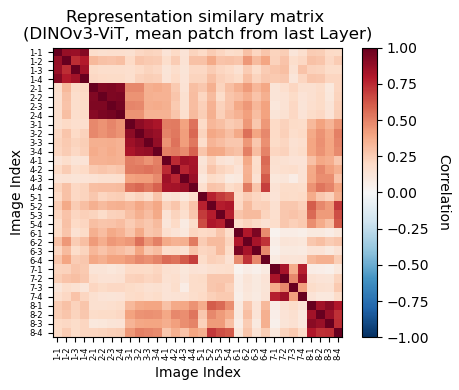

In [22]:
# use the mean patch last as the image representation to do a correlation matrix visualization
# use matplotlib only no seaborn
import matplotlib.pyplot as plt
import numpy as np
corr = np.corrcoef(pooled_block_features[-1])  # (B,B) correlation matrix of the last block pooled features
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similary matrix \n(DINOv3-ViT, mean patch from last Layer)")
# show image as 1-1, 1-2 etc, as class 1, instance 1 and 2
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.xticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2925409/2706492217.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


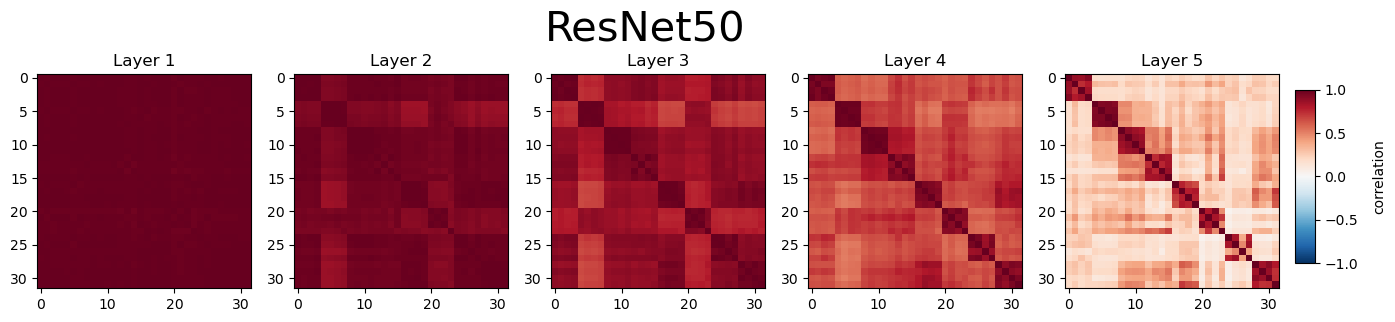

In [ ]:
# visualize the rcm for different layers
import matplotlib.pyplot as plt
layers = ['layer1', 'layer2', 'layer3', 'layer4', 'layer5']
nlayers = len(layers)
fig, axes = plt.subplots(1, nlayers, figsize=(2*nlayers+3, 3))
axes = axes.ravel()
for li in range(nlayers):
    reps = pooled_block_features[li]  # (B,C)
    C = np.corrcoef(reps)
    img = axes[li].imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[li].set_title(f"Layer {li+1}")
plt.suptitle("ResNet50", fontsize=30)
pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.1, pos.y0-0.07, 0.015, pos.height])

cbar = fig.colorbar(img, cax=cax)
cbar.set_label('correlation', rotation=90, labelpad=10)
plt.tight_layout()
# save the figure
plt.savefig("../figures/resnet_corr_matrix.png", dpi=300, bbox_inches='tight')

plt.show()